# Tamil sentiment: tamil-sentiment-distilbert

Using this [model](https://huggingface.co/Vasanth/tamil-sentiment-distilbert) and this [dataset](https://huggingface.co/datasets/community-datasets/tamilmixsentiment), both from HuggingFace (s/o Michael for finding these!).

## Setup

In [1]:
import torch

# setting up local server to use my laptop's GPU (doc here at https://docs.pytorch.org/docs/stable/notes/mps.html)
print('MPS available:', torch.backends.mps.is_available())
print('MPS built:', torch.backends.mps.is_built())

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Using device:', device)

MPS available: True
MPS built: True
Using device: mps


In [2]:
# no peft/bitsandbytes/accelerate needed since tamil model is just a distilbert classifier
!pip install -q -U transformers torch pandas scikit-learn matplotlib tqdm


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import pandas as pd

DATASET_ROOT = '/Users/michelle/Library/CloudStorage/GoogleDrive-xsmichelletk@gmail.com/.shortcut-targets-by-id/1BGQNTF4wTH0-VPksYIDj3o34N8lnu8WD/IAT 360 Final Project/Datasets'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'Train')
TEST_DIR = os.path.join(DATASET_ROOT, 'Test')

print('Train folder contents:', os.listdir(TRAIN_DIR))
print('Test folder contents :', os.listdir(TEST_DIR))

Train folder contents: ['df_base_training_cleaned.csv']
Test folder contents : ['df_korean_qwen_predictions_checkpoint.csv', 'df_english_roberta_predictions.csv', 'checkpoint_english_roberta.csv', '.DS_Store', 'df_all_roberta_predictions.csv', 'df_english_roberta_predictions_v2.csv', 'df_tamil_distilbert_predictions.csv', 'df_hinglish_cleaned.csv', 'df_korean_cleaned.csv', 'df_english_cleaned.csv', 'df_tamil_cleaned.csv', 'df_hinglish_predictions.csv']


## Load + clean the Tamil test set

In [4]:
TAMIL_TEST_CSV = os.path.join(TEST_DIR, 'df_tamil_cleaned.csv')

df_tamil_test = pd.read_csv(TAMIL_TEST_CSV)

# found 84 duplicate rows in df_tamil_cleaned.csv so dropping them here
dupes = df_tamil_test.duplicated().sum()
df_tamil_test = df_tamil_test.drop_duplicates().reset_index(drop=True)
print(f'Dropped {dupes} duplicate rows')

print(df_tamil_test.shape)
print(df_tamil_test['Sentiment'].value_counts())
df_tamil_test.head()

Dropped 84 duplicate rows
(10274, 2)
Sentiment
Positive    7552
Negative    1448
Neutral     1274
Name: count, dtype: int64


,CommentText,Sentiment
0,Trailer late ah parthavanga like podunga,Positive
1,Move pathutu vanthu trailer pakurvnga yaru,Positive
2,Puthupetai dhanush ah yarellam pathinga,Positive
3,"Dhanush oda character ,puthu sa erukay , mass ta",Positive
4,vera level ippa pesungada mokka nu thalaivaaaaaa,Positive


In [5]:
from sklearn.model_selection import train_test_split

# splitting the data, with aaron's help
train_df, test_df = train_test_split(
    df_tamil_test, test_size=0.2, stratify=df_tamil_test['Sentiment'], random_state=42
)

print(f"Test set size: {len(test_df)}")
print(test_df['Sentiment'].value_counts())

Test set size: 2055
Sentiment
Positive    1510
Negative     290
Neutral      255
Name: count, dtype: int64


##Load Model

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# loading straight from the model card (https://huggingface.co/Vasanth/tamil-sentiment-distilbert)
MODEL_ID = 'Vasanth/tamil-sentiment-distilbert'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(device)
model.eval()

print('Model id2label:', model.config.id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model id2label: {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4'}


##Fine-tuning

In [7]:
from sklearn.model_selection import train_test_split as tts

# carving a validation slice out of train_df so early stopping never touches test_df
ft_train_df, ft_val_df = tts(
    train_df, test_size=0.15, stratify=train_df['Sentiment'], random_state=42
)

print(f"Fine-tuning train size: {len(ft_train_df)}")
print(f"Fine-tuning val size: {len(ft_val_df)}")

Fine-tuning train size: 6986
Fine-tuning val size: 1233


In [8]:
# our ground truth only has 3 classes (Positive/Negative/Neutral) but the pretrained
# model has 5, so reinitializing the classification head to match our labels instead (with help from https://huggingface.co/docs/transformers/en/model_doc/auto)
label2id = {
    'Positive': 0,
    'Negative': 1,
    'Neutral': 2,
}
id2label = {
    0: 'Positive',
    1: 'Negative',
    2: 'Neutral',
}

ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    # 3-class head is a different shape than the pretrained 5-class one, so this
    # tells transformers to drop the old head's weights and randomly init a new one instead (with help from https://discuss.huggingface.co/t/mismatched-sizes-error-when-reloading-model/16220)
    ignore_mismatched_sizes=True,
).to(device)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: Vasanth/tamil-sentiment-distilbert
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([5, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([5]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [9]:
from datasets import Dataset

# converting our pandas dataframe to HF Dataset obj
# (with help from https://huggingface.co/docs/datasets/en/use_with_pandas)
def to_hf_dataset(df):
    ds = Dataset.from_pandas(df[['CommentText', 'Sentiment']].reset_index(drop=True))
    ds = ds.map(lambda ex: {'label': label2id[ex['Sentiment']]})
    # tokenizing every row up front, run in chunks with batched=True with help from https://huggingface.co/docs/datasets/en/process#map)
    return ds.map(
        lambda ex: tokenizer(ex['CommentText'], truncation=True, max_length=64, padding='max_length'),
        batched=True,
    )

train_dataset = to_hf_dataset(ft_train_df)
val_dataset = to_hf_dataset(ft_val_df)

Map:   0%|          | 0/6986 [00:00<?, ? examples/s]

Map:   0%|          | 0/6986 [00:00<?, ? examples/s]

Map:   0%|          | 0/1233 [00:00<?, ? examples/s]

Map:   0%|          | 0/1233 [00:00<?, ? examples/s]

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
    }

In [17]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# high epoch cap/early-stop on val loss and restore the best checkpoint (with help from https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)
training_args = TrainingArguments(
    output_dir='./tamil_distilbert_finetuned',
    num_train_epochs=15,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    logging_steps=50,
    report_to='none',
)

# patience=2 means training stops if val loss doesn't improve for 2 epochs in a row
trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.487359,0.798644,0.718573,0.401483
2,0.549215,0.800037,0.701541,0.417070
3,0.492212,0.831945,0.698297,0.437370


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=657, training_loss=0.5187685369900917, metrics={'train_runtime': 170.0154, 'train_samples_per_second': 616.356, 'train_steps_per_second': 19.322, 'total_flos': 347037656442624.0, 'train_loss': 0.5187685369900917, 'epoch': 3.0})

In [22]:
# saving locally so i don't have to retrain every time the notebook reruns
FT_MODEL_PATH = os.path.join(TEST_DIR, '..', 'tamil_distilbert_finetuned')
trainer.save_model(FT_MODEL_PATH)
tokenizer.save_pretrained(FT_MODEL_PATH)
print(f'Saved fine-tuned model to {FT_MODEL_PATH}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to /Users/michelle/Library/CloudStorage/GoogleDrive-xsmichelletk@gmail.com/.shortcut-targets-by-id/1BGQNTF4wTH0-VPksYIDj3o34N8lnu8WD/IAT 360 Final Project/Datasets/Test/../tamil_distilbert_finetuned


In [23]:
# building a class-balanced test set, separate from the fine-tuning data, per the
# rubric's requirement, undersampling down to the smallest class's count so
# Positive/Negative/Neutral are equally represented. groupby(...).apply(sample) grabs
# an equal-sized random sample from each Sentiment group (with help from https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.apply.html)
min_class_size = test_df['Sentiment'].value_counts().min()

balanced_parts = []
for sentiment in test_df['Sentiment'].unique():
    subset = test_df[test_df['Sentiment'] == sentiment]
    balanced_parts.append(subset.sample(n=min_class_size, random_state=42))

balanced_test_df = pd.concat(balanced_parts, ignore_index=True)

print(balanced_test_df['Sentiment'].value_counts())

Sentiment
Positive    255
Negative    255
Neutral     255
Name: count, dtype: int64


## Classify

In [25]:
def predict_sentiment(comment: str, max_length: int = 512) -> str:
    inputs = tokenizer(
        str(comment), return_tensors='pt', truncation=True, max_length=max_length
    ).to(device)

    with torch.no_grad():
        logits = ft_model(**inputs).logits

    pred_id = logits.argmax(dim=-1).item()
    return ft_model.config.id2label[pred_id]

In [26]:
from tqdm.auto import tqdm
import time

# running the full tamil set instead of subsampling since it's a light/fast model
SAMPLE_SIZE = None  # None = run on all rows
CHECKPOINT_EVERY = 100  # save progress every N comments
CHECKPOINT_PATH = os.path.join(TEST_DIR, 'df_tamil_distilbert_predictions_checkpoint.csv')

# build the eval set w/ balanced test split
eval_df = (
    balanced_test_df.sample(n=SAMPLE_SIZE, random_state=42) if SAMPLE_SIZE else balanced_test_df
).reset_index(drop=True)

# resume from checkpoint (if it exists)
if os.path.exists(CHECKPOINT_PATH):
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    print(f"Found checkpoint with {len(checkpoint_df)} predictions already done. Resuming...")
    eval_df['Predicted_Sentiment'] = checkpoint_df['Predicted_Sentiment'].reindex(eval_df.index)
else:
    eval_df['Predicted_Sentiment'] = pd.NA
    print("No checkpoint found. Starting fresh.")

remaining_idx = eval_df.index[eval_df['Predicted_Sentiment'].isna()]
print(f"{len(remaining_idx)} comments left to classify out of {len(eval_df)} total.")

start_time = time.time()
for count, idx in enumerate(tqdm(remaining_idx, desc='Classifying with fine-tuned tamil-sentiment-distilbert')):
    comment = eval_df.loc[idx, 'CommentText']
    eval_df.loc[idx, 'Predicted_Sentiment'] = predict_sentiment(comment)

    # save a checkpoint periodically so a disconnect doesn't lose all progress
    if (count + 1) % CHECKPOINT_EVERY == 0:
        eval_df.to_csv(CHECKPOINT_PATH, index=False)

# final save
eval_df.to_csv(CHECKPOINT_PATH, index=False)
elapsed = time.time() - start_time
print(f"Done. Classified {len(remaining_idx)} comments in {elapsed/60:.1f} minutes.")
eval_df.head()

No checkpoint found. Starting fresh.
765 comments left to classify out of 765 total.


Classifying with fine-tuned tamil-sentiment-distilbert:   0%|          | 0/765 [00:00<?, ?it/s]

Done. Classified 765 comments in 0.1 minutes.


,CommentText,Sentiment,Predicted_Sentiment
0,தலைவா....ur great...no words to say...loveeeee...,Positive,Positive
1,Ithu Maari Neraiya Neriya Neriya Padam Nadinga...,Positive,Positive
2,Ufff semmayo semmaa .. ennna superuuuuuuuuuuuu...,Positive,Positive
3,Adiye Meera ni vikram vedhala Madhavan kuda na...,Positive,Positive
4,Vfx work is Awesome like Hollywood movie,Positive,Neutral


In [27]:
# save predictions back to our shared Drive so the rest of the group can reuse them
RESULTS_PATH = os.path.join(TEST_DIR, 'df_tamil_distilbert_predictions.csv')
eval_df.to_csv(RESULTS_PATH, index=False)
print(f'Saved predictions to {RESULTS_PATH}')

Saved predictions to /Users/michelle/Library/CloudStorage/GoogleDrive-xsmichelletk@gmail.com/.shortcut-targets-by-id/1BGQNTF4wTH0-VPksYIDj3o34N8lnu8WD/IAT 360 Final Project/Datasets/Test/df_tamil_distilbert_predictions.csv


## Confusion matrix

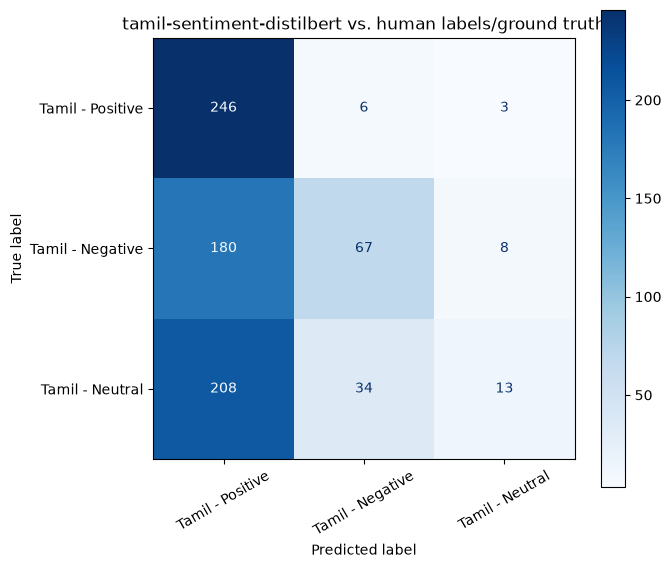

                  precision    recall  f1-score   support

Tamil - Positive       0.39      0.96      0.55       255
Tamil - Negative       0.63      0.26      0.37       255
 Tamil - Neutral       0.54      0.05      0.09       255

        accuracy                           0.43       765
       macro avg       0.52      0.43      0.34       765
    weighted avg       0.52      0.43      0.34       765



In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

#took out unknown now
LABEL_ORDER = ['Positive', 'Negative', 'Neutral']
DISPLAY_LABELS = ['Tamil - Positive', 'Tamil - Negative', 'Tamil - Neutral']

y_true = eval_df['Sentiment']
y_pred = eval_df['Predicted_Sentiment']

cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DISPLAY_LABELS)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title('tamil-sentiment-distilbert vs. human labels/ground truth')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=LABEL_ORDER, target_names=DISPLAY_LABELS))